In [1]:
import os
import calendar
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial import KDTree
from datetime import date

In [12]:
# ===== USER CONFIGURATION =====

# --- Paths ---
data_path  = os.path.expanduser('../test-data/v3.LR.historical_thkConc_ensembleStats')
mesh_file  = os.path.expanduser('../test-data/mpaso-IcoswISC30E3r5-restart.nc')
output_dir = os.path.expanduser('../figures')

# --- Route waypoint text file ---
# Format: one waypoint per line -> lat_deg, lon_deg, cumulative_dist_nm
# Lines beginning with '#' are treated as comments and ignored.
route_file_txt = os.path.expanduser('../test-data/text_route4.txt')
route_label    = os.path.splitext(os.path.basename(route_file_txt))[0]  # or set manually

# --- Years to include ---
year_start = 2020
year_end   = 2039
years = [str(y) for y in range(year_start, year_end + 1)]

# --- Output ---
save_figs = True   # set False to suppress file saving

# --- x-axis centering ---
# 0-based day-of-year to place at the centre of the heatmap x-axis.
# 258 ~ September 16, near the annual Arctic sea-ice minimum.
plot_center_doy = 258

# --- Spatial interpolation ---
# Number of nearest MPAS mesh cells to average over at each route waypoint
k_neighbors = 4

# --- Colormap limits ---
# Ice concentration is the ice area fraction (0–1).
# Ice volume/area is the grid-cell-mean effective thickness (m).
conc_vmin, conc_vmax = 0.0, 1.0
thk_vmin,  thk_vmax  = 0.0, 4.0

# --- Trend analysis ---
# Ensemble statistic to analyse.  Options: 'median', '5th_percentile', '95th_percentile'
trend_stat             = 'median'
# trend_stat             = '5th_percentile'
# trend_stat             = '95th_percentile'
# Threshold values for detecting spring/fall transitions
# Threshold values for detecting spring/fall transitions
trend_threshold_conc   = 0.5    # ice area fraction (0–1)
trend_threshold_thk    = 0.25    # effective ice thickness (m)
# Rolling-average window (days) applied to each year before threshold detection
trend_rolling_window   = 14
# DOY search windows (0-based): spring melt and fall freeze
#trend_spring_doy_range = (60, 180)    # roughly Mar–Jun
trend_spring_doy_range = (121, 182)    # roughly May–July
#trend_fall_doy_range   = (243, 335)   # roughly Sep–Dec
trend_fall_doy_range   = (305, 365)   # roughly Nov–Jan
# Output directory for trend scatter plots.
# Set to a different path here to redirect figures without changing output_dir.
trend_output_dir       = output_dir
# Y-axis limits for trend scatter plots.
# None = auto-fit each panel to its data range (with 14-day padding on each side).
# Set to a (min_doy, max_doy) tuple to fix both panels to the same range,
# e.g. trend_scatter_ylim = (100, 200) to show only May–Jul.
trend_scatter_ylim     = None


In [3]:
print('Loading MPAS mesh...')
ds_mesh = xr.open_dataset(mesh_file)

rad2deg       = 180.0 / np.pi
lat_mesh_full = ds_mesh.latCell.values * rad2deg
lon_mesh_full = ds_mesh.lonCell.values * rad2deg

# Normalise longitudes to [-180, 180]
lon_mesh_full = np.where(lon_mesh_full > 180.0,
                         lon_mesh_full - 360.0,
                         lon_mesh_full)

# Restrict to cells at or north of 60 deg N
ind_north = np.where(lat_mesh_full >= 60.0)[0]
lat_mesh  = lat_mesh_full[ind_north]
lon_mesh  = lon_mesh_full[ind_north]

print(f'  Total mesh cells  : {len(lat_mesh_full):,}')
print(f'  Cells >= 60 deg N : {len(lat_mesh):,}')

Loading MPAS mesh...
  Total mesh cells  : 465,044
  Cells >= 60 deg N : 22,076


In [4]:
# ---- Load route waypoints from text file ----
print(f'Loading route from {route_file_txt} ...')

wp_lat_list  = []
wp_lon_list  = []
wp_dist_list = []

with open(route_file_txt) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = [p.strip() for p in line.split(',')]
        if len(parts) < 3:
            continue
        wp_lat_list.append(float(parts[0]))
        wp_lon_list.append(float(parts[1]))
        wp_dist_list.append(float(parts[2]))

trans_lat  = np.array(wp_lat_list)
trans_lon  = np.array(wp_lon_list)
cumul_dist = np.array(wp_dist_list)

seg_dist_nm   = np.diff(cumul_dist, prepend=0.0)
total_dist_nm = float(np.max(cumul_dist))

print(f'  Waypoints       : {len(trans_lat)}')
print(f'  Total distance  : {total_dist_nm:.1f} nm')
print(f'  Route label     : {route_label}')

# Build KDTree over the northern-hemisphere restricted mesh
print('Building KDTree...')
tree = KDTree(list(zip(lon_mesh, lat_mesh)))
_, inds = tree.query(list(zip(trans_lon, trans_lat)), k=k_neighbors)
print(f'  KDTree ready.  Neighbor index array shape: {inds.shape}')

Loading route from ../test-data/text_route4.txt ...
  Waypoints       : 1
  Total distance  : 100.0 nm
  Route label     : text_route4
Building KDTree...
  KDTree ready.  Neighbor index array shape: (1, 4)


In [5]:
def _doy_index(year, month, day):
    """Return 0-based day-of-year index (0 = Jan 1)."""
    return (date(year, month, day) - date(year, 1, 1)).days


def _find_files(years, data_path):
    """Return sorted list of (year, month, filepath) tuples for available monthly files."""
    prefix  = 'v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.'
    records = []
    for yr in years:
        for mo in range(1, 13):
            fname = os.path.join(data_path, f'{prefix}{yr}-{mo:02d}-01.nc')
            if os.path.exists(fname):
                records.append((int(yr), mo, fname))
    return records


# ---- Read and cache raw sea ice data ----
# raw_seaice_data holds a list of
# (year, month, conc_med, conc_5th, conc_95th, thk_med, thk_5th, thk_95th)
# where each array has shape (n_days_in_month, n_arctic_cells).

file_records = _find_files(years, data_path)

if not file_records:
    raise FileNotFoundError(
        f'No sea ice ensemble stats files found in {data_path} for years {years}.'
    )

raw_seaice_data = []
for yr, mo, fpath in file_records:
    print(f'  {os.path.basename(fpath)}')
    ds = xr.open_dataset(fpath)

    conc_med  = ds['timeDaily_avg_iceAreaCell_ensembleMedian'].values
    conc_5th  = ds['timeDaily_avg_iceAreaCell_ensemble5th'].values
    conc_95th = ds['timeDaily_avg_iceAreaCell_ensemble95th'].values
    thk_med   = ds['timeDaily_avg_iceVolumeCell_ensembleMedian'].values
    thk_5th   = ds['timeDaily_avg_iceVolumeCell_ensemble5th'].values
    thk_95th  = ds['timeDaily_avg_iceVolumeCell_ensemble95th'].values
    ds.close()

    raw_seaice_data.append((yr, mo,
                            conc_med, conc_5th, conc_95th,
                            thk_med,  thk_5th,  thk_95th))

print(f'\nRaw data read complete. {len(raw_seaice_data)} file(s) cached.')

  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-01-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-02-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-03-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-04-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-05-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-06-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-07-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-08-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-09-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-10-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-11-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.2020-12-01.nc
  v3.LR.historical_EnsStats.mpassi.hist.am.timeSeriesStatsDaily.

In [6]:
# ---- Route-specific extraction ----
# For each day, average k nearest-neighbor cell values at each waypoint,
# then take the route-maximum (highest ice = worst-case conditions).

avail_years  = sorted(set(yr for yr, *_ in raw_seaice_data))
n_years      = len(avail_years)
year_idx_map = {yr: i for i, yr in enumerate(avail_years)}

shape = (n_years, 366)

max_conc_med  = np.full(shape, np.nan)
max_conc_5th  = np.full(shape, np.nan)
max_conc_95th = np.full(shape, np.nan)
max_thk_med   = np.full(shape, np.nan)
max_thk_5th   = np.full(shape, np.nan)
max_thk_95th  = np.full(shape, np.nan)
max_prod_med  = np.full(shape, np.nan)
max_prod_5th  = np.full(shape, np.nan)
max_prod_95th = np.full(shape, np.nan)

for (yr, mo,
     conc_med_arr, conc_5th_arr, conc_95th_arr,
     thk_med_arr,  thk_5th_arr,  thk_95th_arr) in raw_seaice_data:

    n_days = conc_med_arr.shape[0]
    yi     = year_idx_map[yr]

    for day_idx in range(n_days):
        doy = _doy_index(yr, mo, day_idx + 1)   # 0-based day-of-year

        # Average k neighbours at each route waypoint: shape (n_waypoints,)
        wp_conc_med  = np.mean(conc_med_arr [day_idx, inds], axis=1)
        wp_conc_5th  = np.mean(conc_5th_arr [day_idx, inds], axis=1)
        wp_conc_95th = np.mean(conc_95th_arr[day_idx, inds], axis=1)
        wp_thk_med   = np.mean(thk_med_arr  [day_idx, inds], axis=1)
        wp_thk_5th   = np.mean(thk_5th_arr  [day_idx, inds], axis=1)
        wp_thk_95th  = np.mean(thk_95th_arr [day_idx, inds], axis=1)

        # Route-maximum: highest ice along the route (worst-case condition)
        max_conc_med [yi, doy] = float(np.nanmax(wp_conc_med))
        max_conc_5th [yi, doy] = float(np.nanmax(wp_conc_5th))
        max_conc_95th[yi, doy] = float(np.nanmax(wp_conc_95th))
        max_thk_med  [yi, doy] = float(np.nanmax(wp_thk_med))
        max_thk_5th  [yi, doy] = float(np.nanmax(wp_thk_5th))
        max_thk_95th [yi, doy] = float(np.nanmax(wp_thk_95th))
        max_prod_med [yi, doy] = float(np.nanmax(wp_conc_med  * wp_thk_med))
        max_prod_5th [yi, doy] = float(np.nanmax(wp_conc_5th  * wp_thk_5th))
        max_prod_95th[yi, doy] = float(np.nanmax(wp_conc_95th * wp_thk_95th))

print('Route extraction complete.')
print(f'  {n_years} year(s), {len(raw_seaice_data)} file(s) processed.')

Route extraction complete.
  20 year(s), 240 file(s) processed.


In [13]:
# Month start positions (0-based day-of-year) and labels for x-axis ticks
_MONTH_DOY   = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
_MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


def make_seaice_heatmap(data, years, field_label, stat_label,
                        route_label, save_figs, output_dir,
                        vmin, vmax, cmap_name,
                        cbar_label, field_slug,
                        center_doy=258,
                        trend_overlay=None):
    """
    Produce a single sea-ice heatmap figure.

    Parameters
    ----------
    data          : ndarray, shape (n_years, 366)
                    Route-maximum sea ice value for each year/day.
    years         : list of int
    field_label   : str   e.g. 'Ice Concentration', 'Ice Thickness'
    stat_label    : str   e.g. 'Median', '5th Percentile'
    route_label   : str
    save_figs     : bool
    output_dir    : str
    vmin, vmax    : float  colorbar limits
    cmap_name     : str    matplotlib colormap name
    cbar_label    : str    colorbar axis label
    field_slug    : str    short identifier for filenames (e.g. 'conc', 'thk')
    center_doy    : int    0-based DOY to place at the centre of the x-axis
    trend_overlay : dict or None
                    If provided, overlays threshold-crossing scatter points and
                    trend lines on the heatmap.  Expected keys:
                      'spring' and/or 'fall', each a dict with:
                        'yi'        – ndarray of year indices with valid crossings
                        'rolled_x'  – corresponding rolled x-axis positions
                        'slope'     – trend slope (days / year)
                        'intercept' – trend intercept
    """
    n_years  = len(years)
    n_days   = 365         # omit leap-year slot at index 365
    plot_arr = data[:, :n_days].copy()

    # Roll columns so that center_doy sits in the middle of the x-axis
    start_doy = (center_doy - n_days // 2) % n_days
    plot_arr  = np.roll(plot_arr, -start_doy, axis=1)

    # Month positions in the rolled frame
    shifted_starts = [(_MONTH_DOY[m] - start_doy) % n_days for m in range(12)]
    month_order    = sorted(range(12), key=lambda m: shifted_starts[m])

    # Derive vmax from the data when not explicitly provided
    if vmax is None:
        vmax = float(np.nanmax(plot_arr)) if np.any(np.isfinite(plot_arr)) else 1.0

    fig_height = max(3.5, n_years * 0.50 + 2.0)
    fig, ax = plt.subplots(figsize=(16, fig_height))

    extent = [-0.5, n_days - 0.5, -0.5, n_years - 0.5]

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad(color='lightgrey')
    masked = np.ma.masked_invalid(plot_arr)

    im = ax.imshow(masked, aspect='auto', origin='lower',
                   cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=extent, interpolation='none')

    cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.03)
    cbar.set_label(cbar_label, fontsize=11)

    # x-axis: month tick marks and vertical grid lines
    tick_positions = [shifted_starts[m] for m in month_order]
    tick_labels    = [_MONTH_NAMES[m] for m in month_order]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_xlim(-0.5, n_days - 0.5)

    for m in range(12):
        pos = shifted_starts[m]
        if 0 < pos < n_days:
            ax.axvline(x=pos, color='white', linewidth=0.6, alpha=0.5)

    # y-axis: one tick per year, earliest year at the bottom
    ax.set_yticks(range(n_years))
    ax.set_yticklabels([str(y) for y in years], fontsize=10)
    ax.set_ylabel('Year', fontsize=11)
    ax.set_xlabel('Month', fontsize=11)

    ax.set_title(
        f'{field_label}  —  {stat_label}  |  Route {route_label}',
        fontsize=12, fontweight='bold'
    )

    # ---- Optional trend overlay ----
    if trend_overlay is not None:
        _overlay_styles = {
            'spring': {'color': 'limegreen', 'marker': 'o', 'label': 'Spring crossing'},
            'fall':   {'color': 'orange',    'marker': 's', 'label': 'Fall crossing'},
        }
        legend_handles = []
        year_arr = np.array(years, dtype=float)
        for season_key, style in _overlay_styles.items():
            ov = trend_overlay.get(season_key)
            if ov is None:
                continue
            # Scatter: actual threshold-crossing positions
            sc = ax.scatter(ov['rolled_x'], ov['yi'],
                            color=style['color'], marker=style['marker'],
                            s=40, zorder=5, edgecolors='black', linewidths=0.5,
                            label=style['label'])
            legend_handles.append(sc)
            # Trend line: predicted crossings for all years
            if not np.isnan(ov['slope']):
                pred_doy    = ov['slope'] * year_arr + ov['intercept']
                pred_rolled = np.array([(d - start_doy) % n_days for d in pred_doy])
                trend_yi    = np.arange(n_years, dtype=float)
                ax.plot(pred_rolled, trend_yi,
                        color=style['color'], linewidth=2, linestyle='--', zorder=4)
        if legend_handles:
            ax.legend(handles=legend_handles, fontsize=8,
                      loc='lower right', framealpha=0.85)

    plt.tight_layout()

    if save_figs:
        os.makedirs(output_dir, exist_ok=True)
        stat_slug = (stat_label.lower()
                     .replace(' ', '_')
                     .replace('th', '')
                     .replace('st', ''))
        overlay_suffix = '_trend' if trend_overlay is not None else ''
        fname = os.path.join(
            output_dir,
            f'seaice_{field_slug}_route{route_label}_{stat_slug}{overlay_suffix}.png'
        )
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'  Saved: {fname}')

    plt.show()
    plt.close(fig)


In [14]:
# ---- Trend analysis helpers ----
from scipy.stats import linregress as _linregress


def smooth_by_year(data, window):
    """
    Apply a centred rolling average along the DOY axis for each year.

    NaN values (missing days) are excluded from each window mean.
    Edge days use a one-sided window rather than reflection padding so
    that NaN values at the end of the array are not mirrored inward.

    Parameters
    ----------
    data   : ndarray, shape (n_years, n_doys)
    window : int   number of days (odd recommended)

    Returns
    -------
    smoothed : ndarray, same shape, NaN where the window is entirely NaN
    """
    if window <= 1:
        return data.copy()
    half     = window // 2
    n_years, n_cols = data.shape
    smoothed = np.full_like(data, np.nan, dtype=float)
    for yi in range(n_years):
        row = data[yi].astype(float)
        for d in range(n_cols):
            d0   = max(0, d - half)
            d1   = min(n_cols, d + half + 1)
            vals = row[d0:d1]
            ok   = vals[~np.isnan(vals)]
            smoothed[yi, d] = np.mean(ok) if len(ok) > 0 else np.nan
    return smoothed


def find_crossing_doy(smoothed_row, threshold, window_start, window_end, find):
    """
    Find the DOY at which a smoothed time-series crosses a threshold.

    Parameters
    ----------
    smoothed_row  : ndarray (n_days,)  smoothed daily values for one year
    threshold     : float
    window_start  : int   first DOY to search (0-based, inclusive)
    window_end    : int   last  DOY to search (0-based, inclusive)
    find          : str
        'last_above'  – last  DOY where smoothed_row >= threshold  (spring melt)
        'first_above' – first DOY where smoothed_row >= threshold  (fall freeze)

    Returns
    -------
    int or float(NaN) : crossing DOY, or NaN if the threshold is not crossed
    """
    doys = np.arange(window_start, min(window_end + 1, len(smoothed_row)))
    vals = smoothed_row[doys]
    above = doys[vals >= threshold]
    if len(above) == 0:
        return np.nan
    return int(above[-1]) if find == 'last_above' else int(above[0])


def compute_trend(doys, years):
    """
    Fit a linear trend (DOY ~ calendar year) and return diagnostics.

    Years with NaN crossing dates are excluded; a warning is printed listing them.

    Parameters
    ----------
    doys  : array-like (n_years,)  crossing DOY per year; NaN = no crossing
    years : array-like (n_years,)  corresponding calendar years

    Returns
    -------
    slope, intercept : float   trend (days / year) and intercept
    r2               : float   coefficient of determination (R²)
    rmse             : float   root-mean-square error of residuals (days)
    valid_years      : ndarray years included in the fit
    valid_doys       : ndarray crossing DOYs included in the fit
    """
    doys  = np.asarray(doys,  dtype=float)
    years = np.asarray(years, dtype=float)
    valid = ~np.isnan(doys)
    excluded = years[~valid].astype(int).tolist()
    if excluded:
        print(f'    WARNING: threshold not crossed in {len(excluded)} year(s): '
              f'{excluded}  — excluded from trend fit.')
    valid_years = years[valid]
    valid_doys  = doys[valid]
    if len(valid_years) < 2:
        print('    WARNING: fewer than 2 valid years — cannot compute trend.')
        return np.nan, np.nan, np.nan, np.nan, valid_years, valid_doys
    res       = _linregress(valid_years, valid_doys)
    r2        = res.rvalue ** 2
    predicted = res.slope * valid_years + res.intercept
    rmse      = float(np.sqrt(np.mean((valid_doys - predicted) ** 2)))
    return res.slope, res.intercept, r2, rmse, valid_years, valid_doys


Plotting Ice Concentration (route-max)  —  5th Percentile ...
  Saved: ../figures/seaice_conc_routetext_route4_5_percentile.png


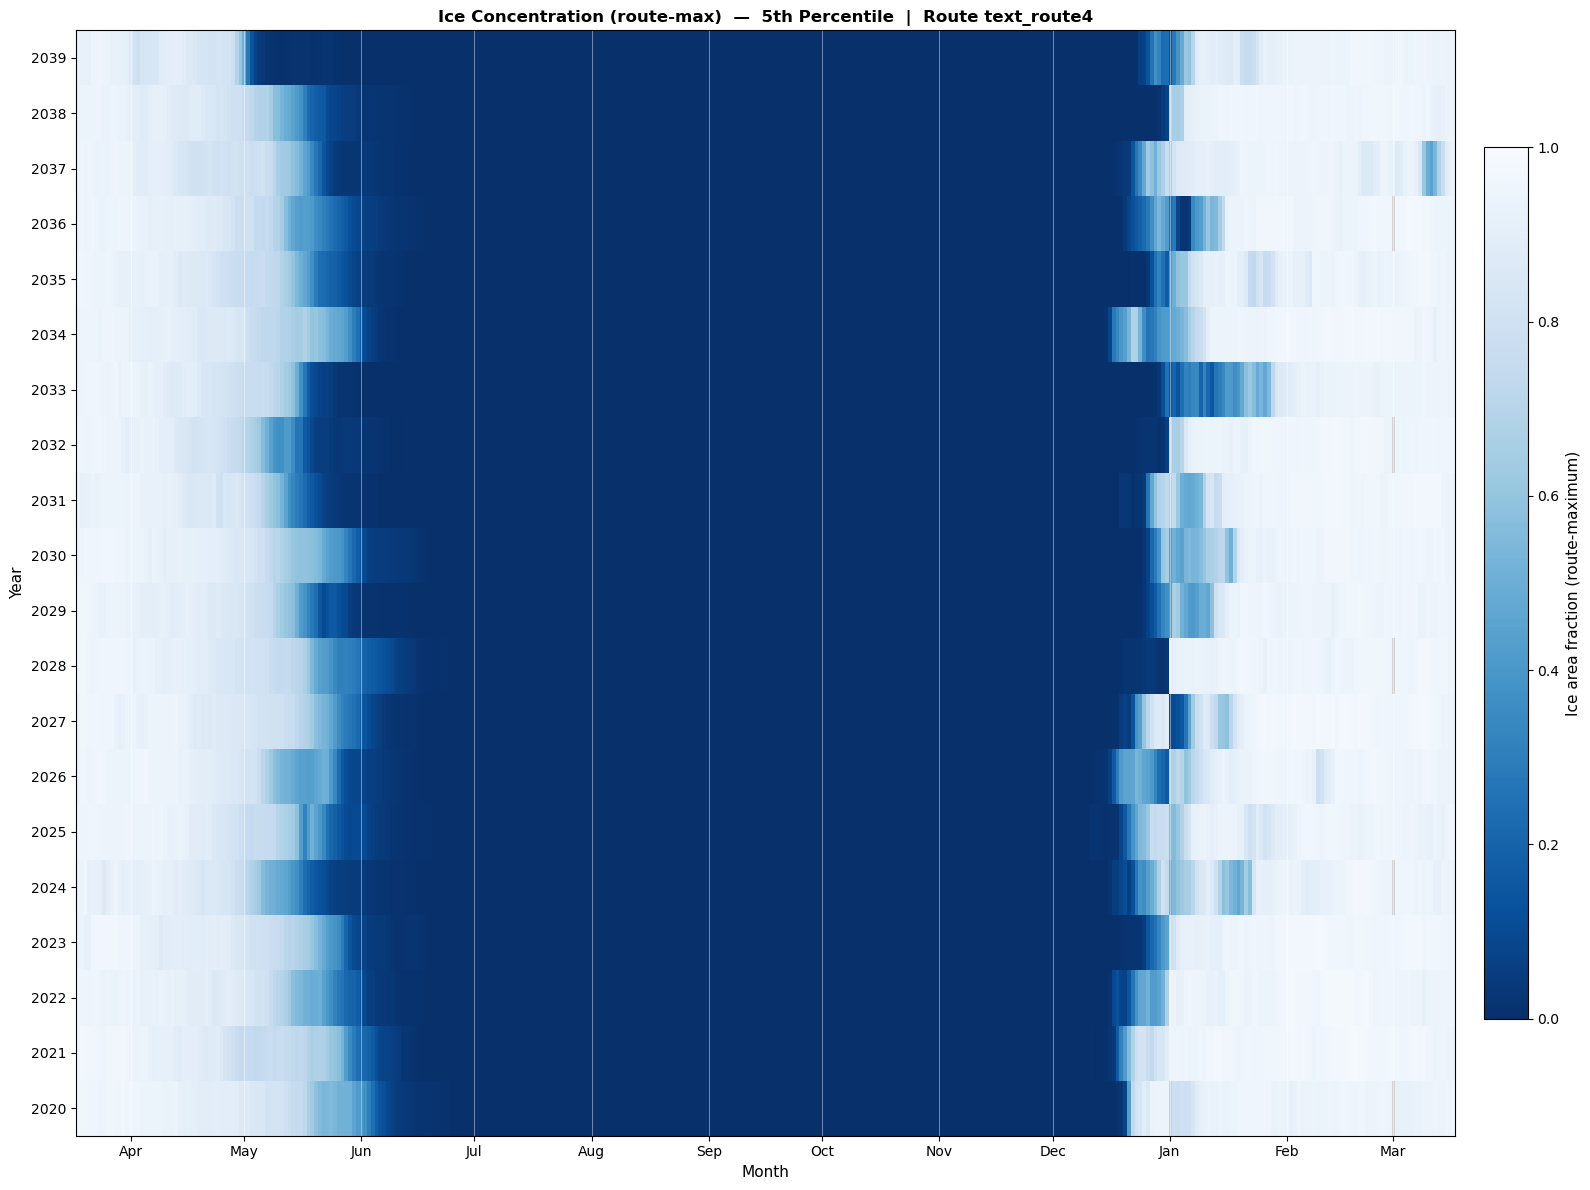

Plotting Ice Concentration (route-max)  —  Median ...
  Saved: ../figures/seaice_conc_routetext_route4_median.png


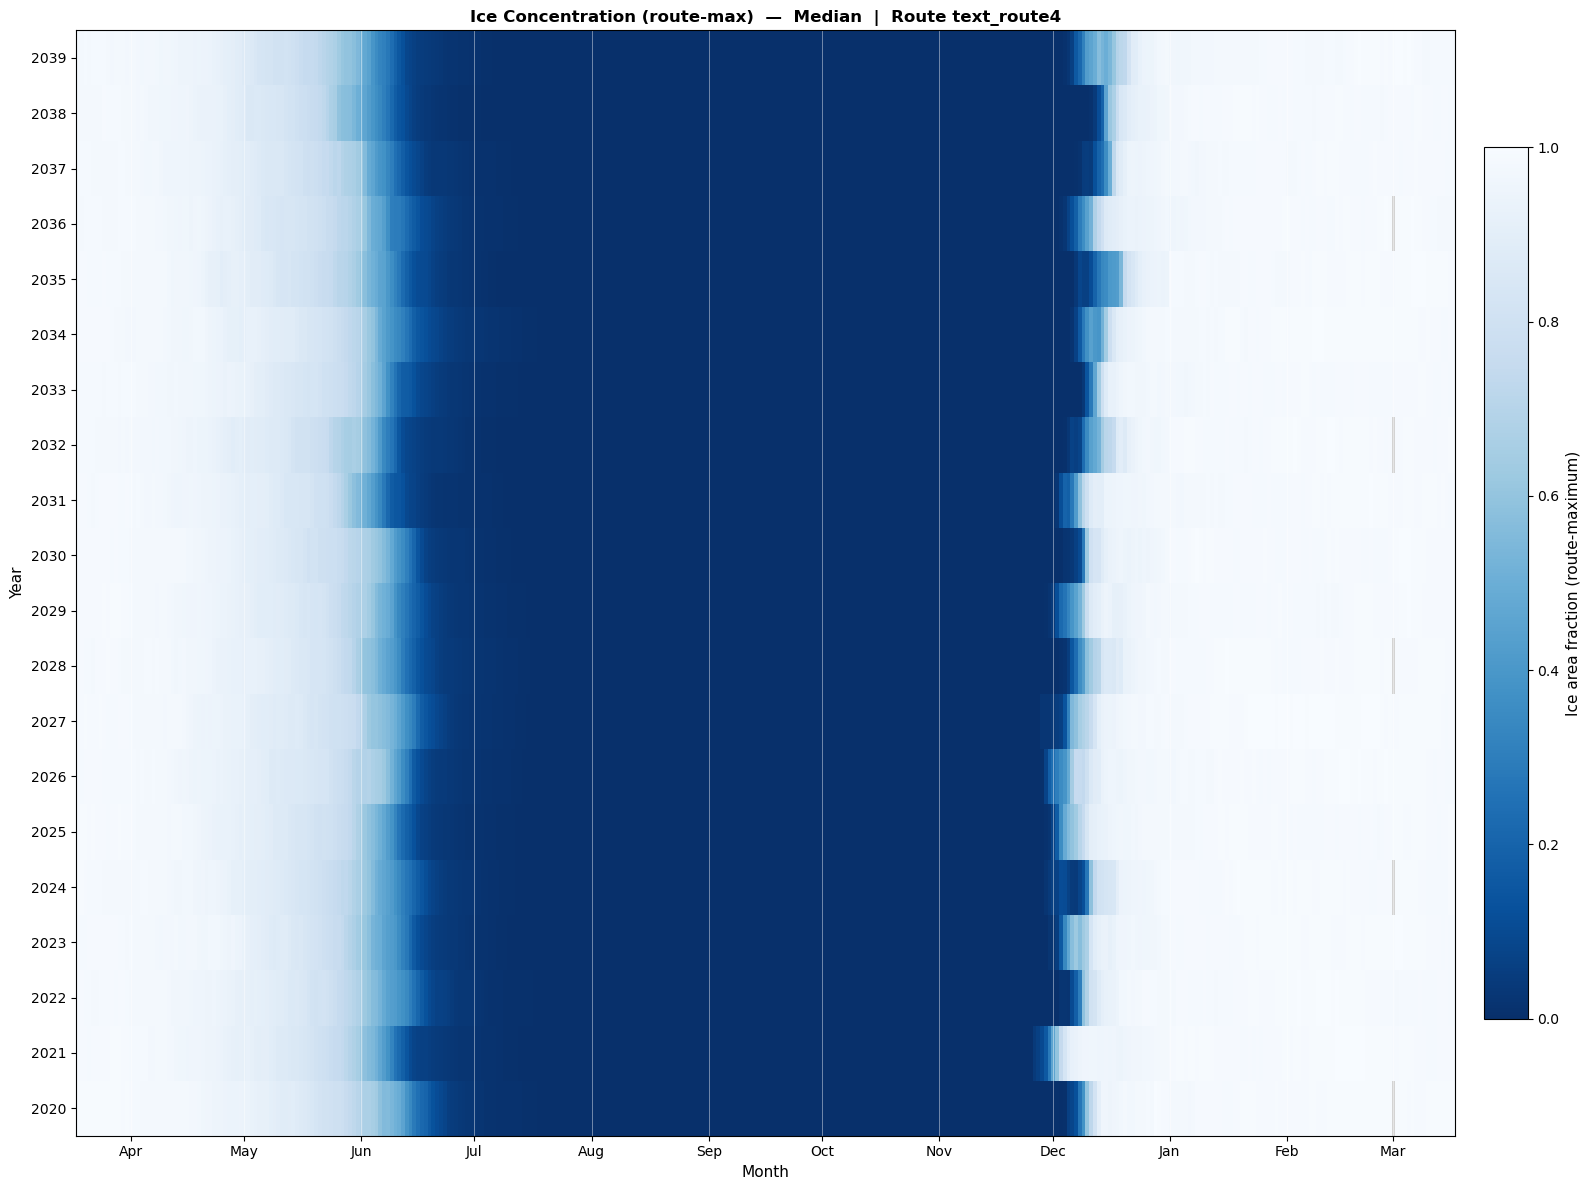

Plotting Ice Concentration (route-max)  —  95th Percentile ...
  Saved: ../figures/seaice_conc_routetext_route4_95_percentile.png


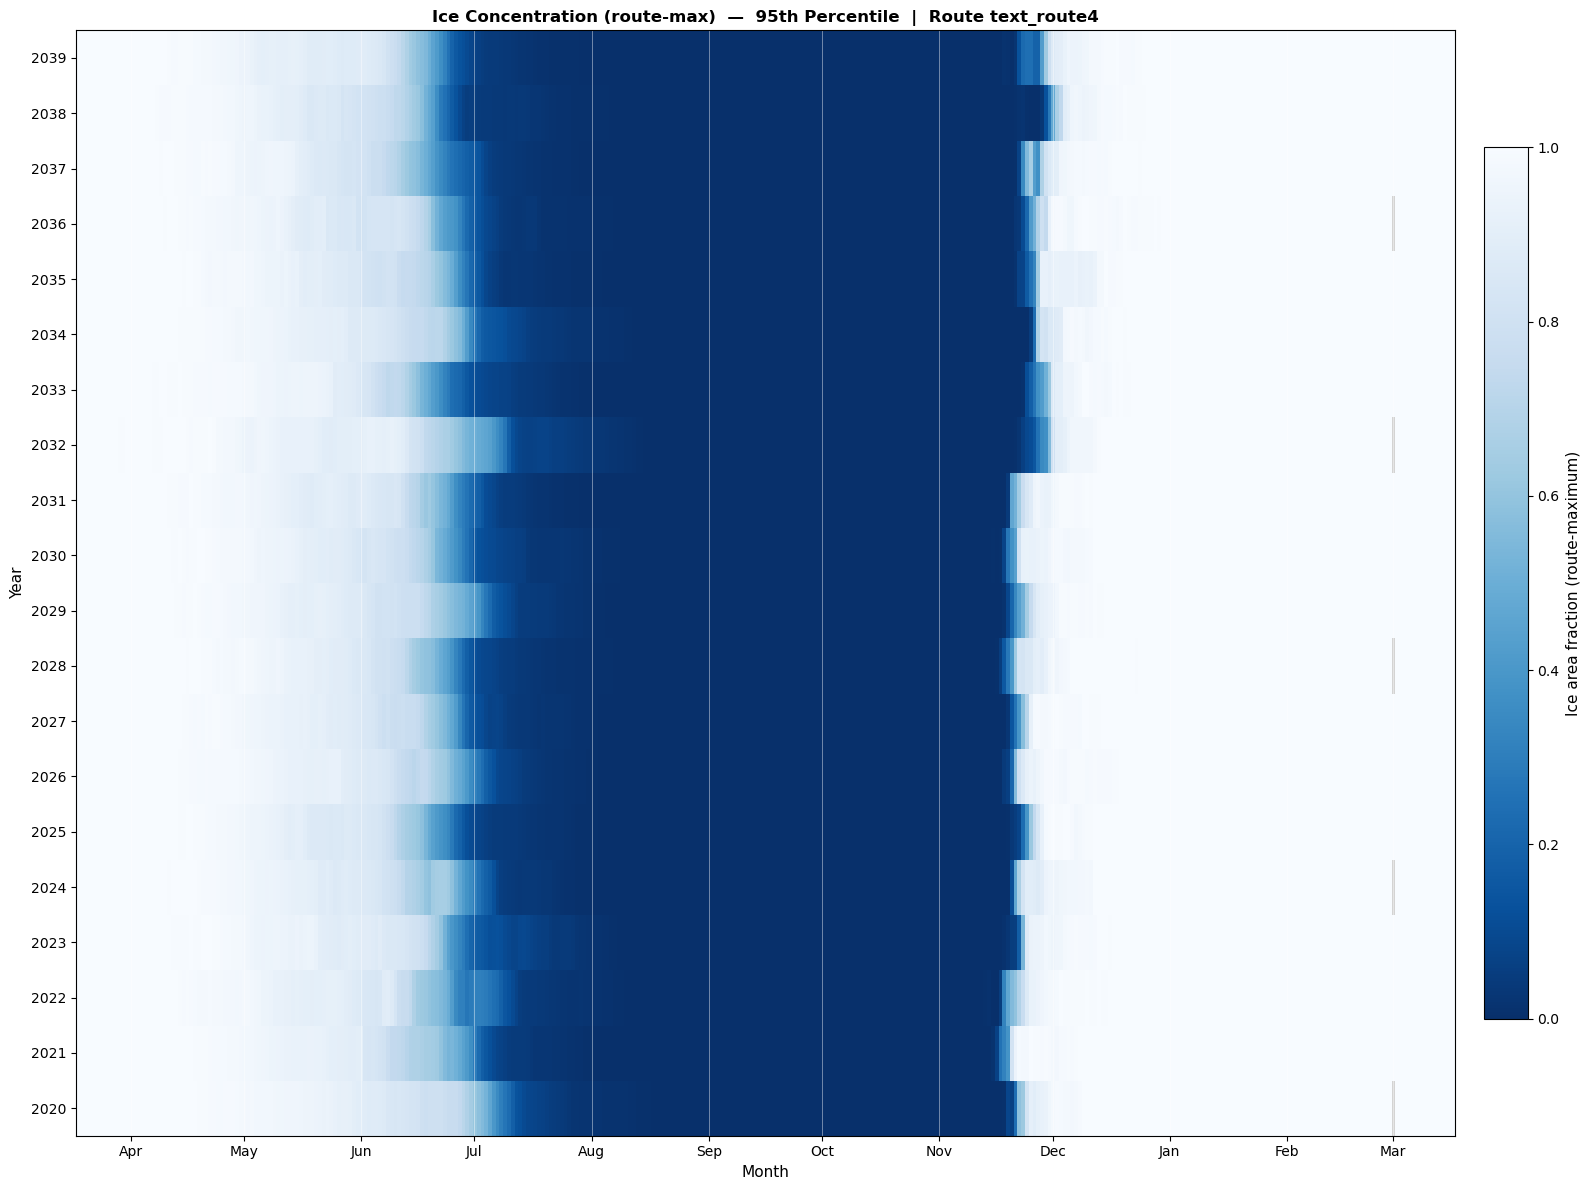

Plotting Ice Thickness (route-max)  —  5th Percentile ...
  Saved: ../figures/seaice_thk_routetext_route4_5_percentile.png


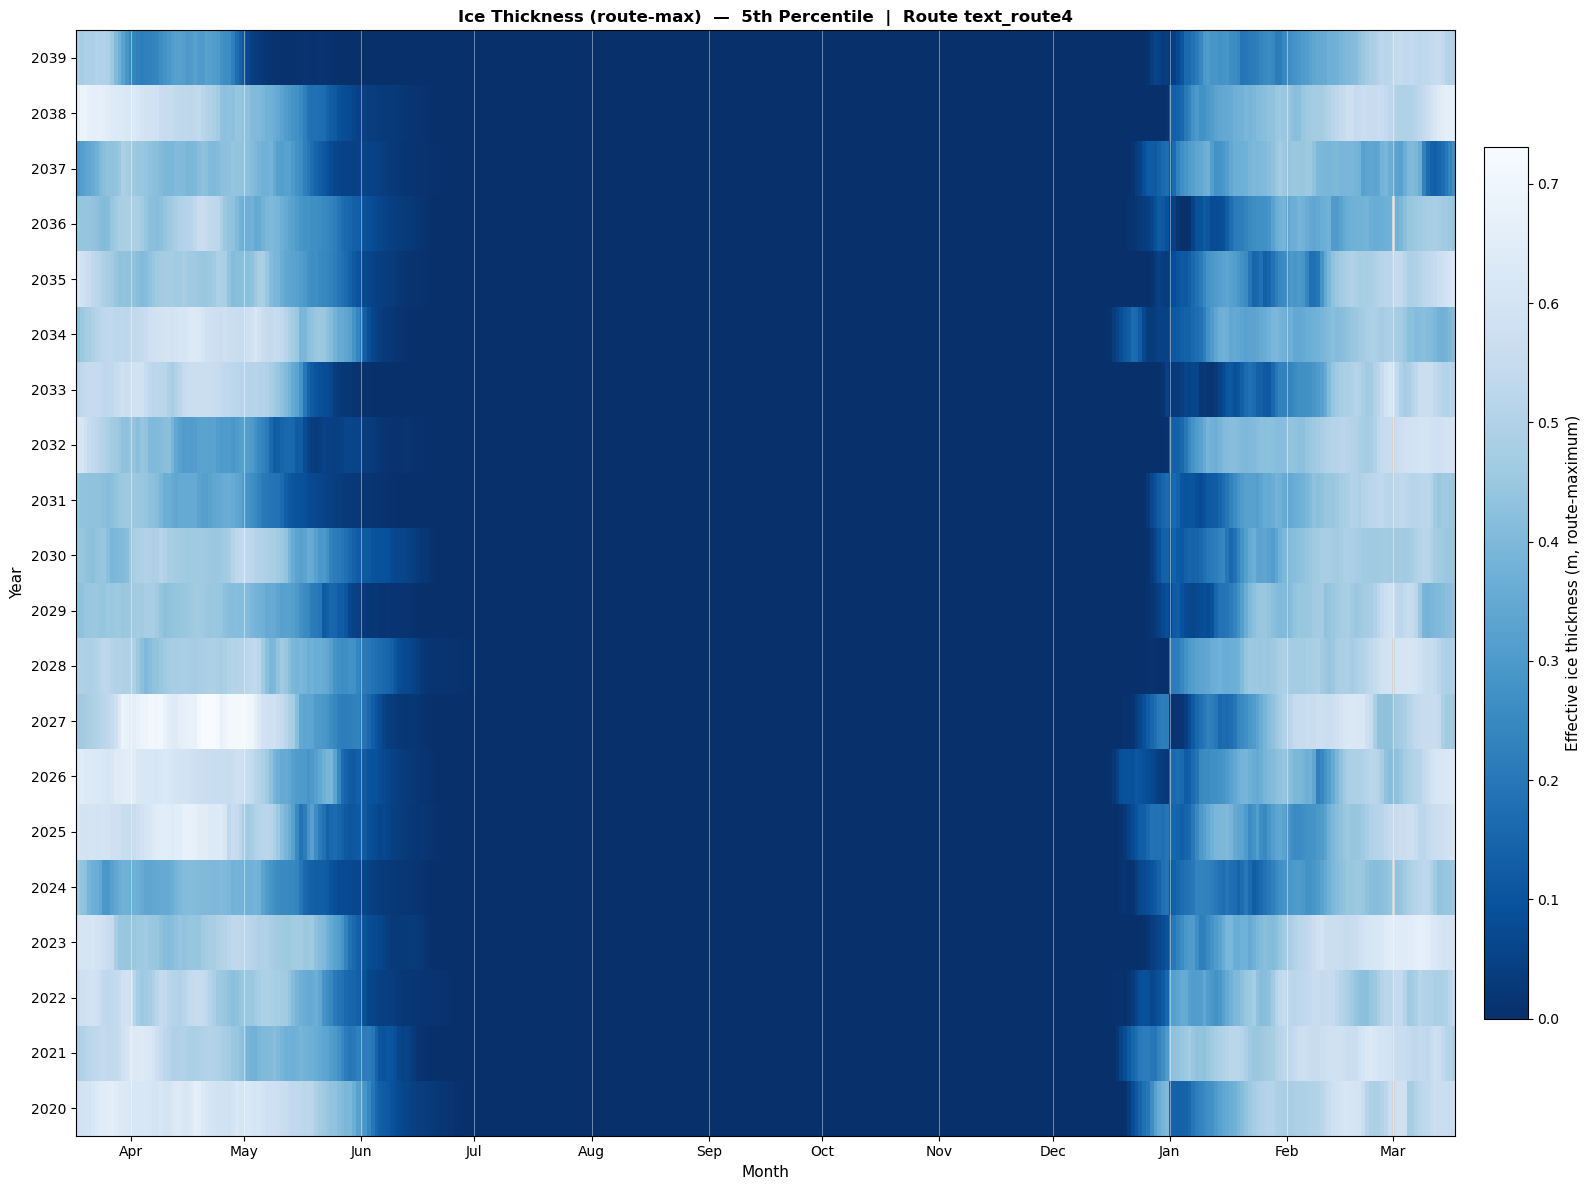

Plotting Ice Thickness (route-max)  —  Median ...
  Saved: ../figures/seaice_thk_routetext_route4_median.png


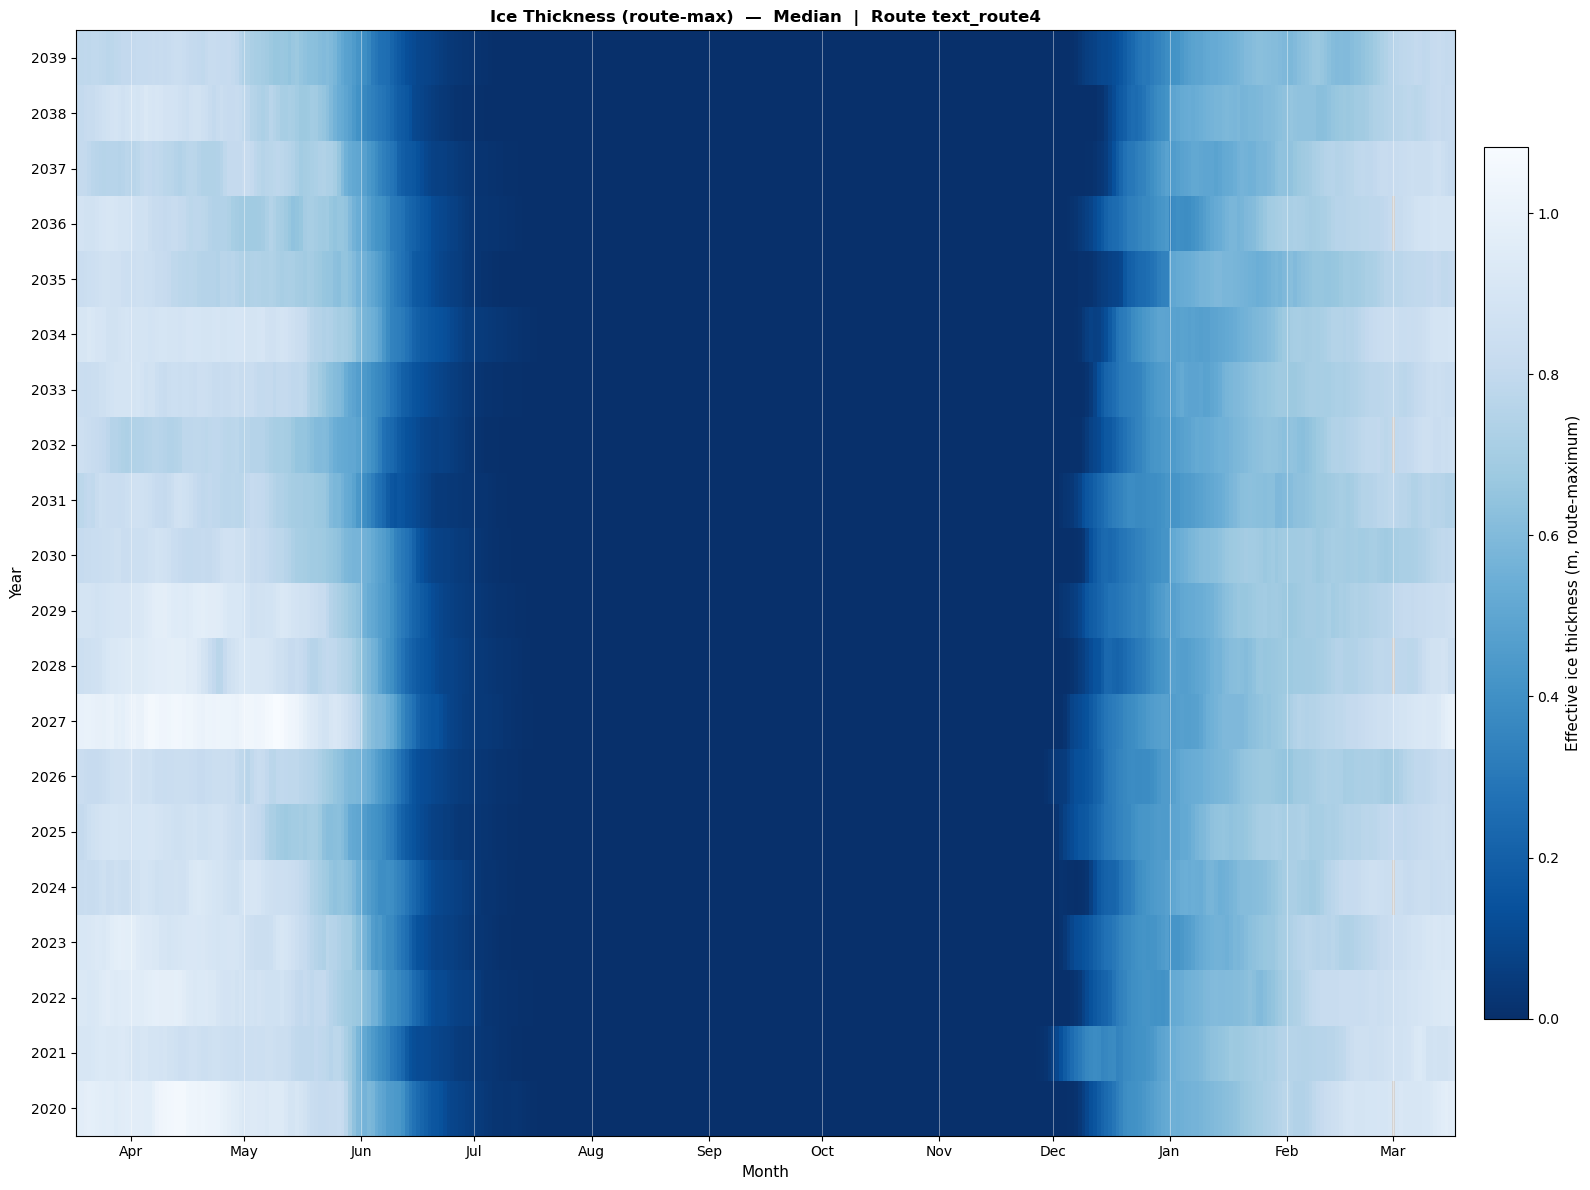

Plotting Ice Thickness (route-max)  —  95th Percentile ...
  Saved: ../figures/seaice_thk_routetext_route4_95_percentile.png


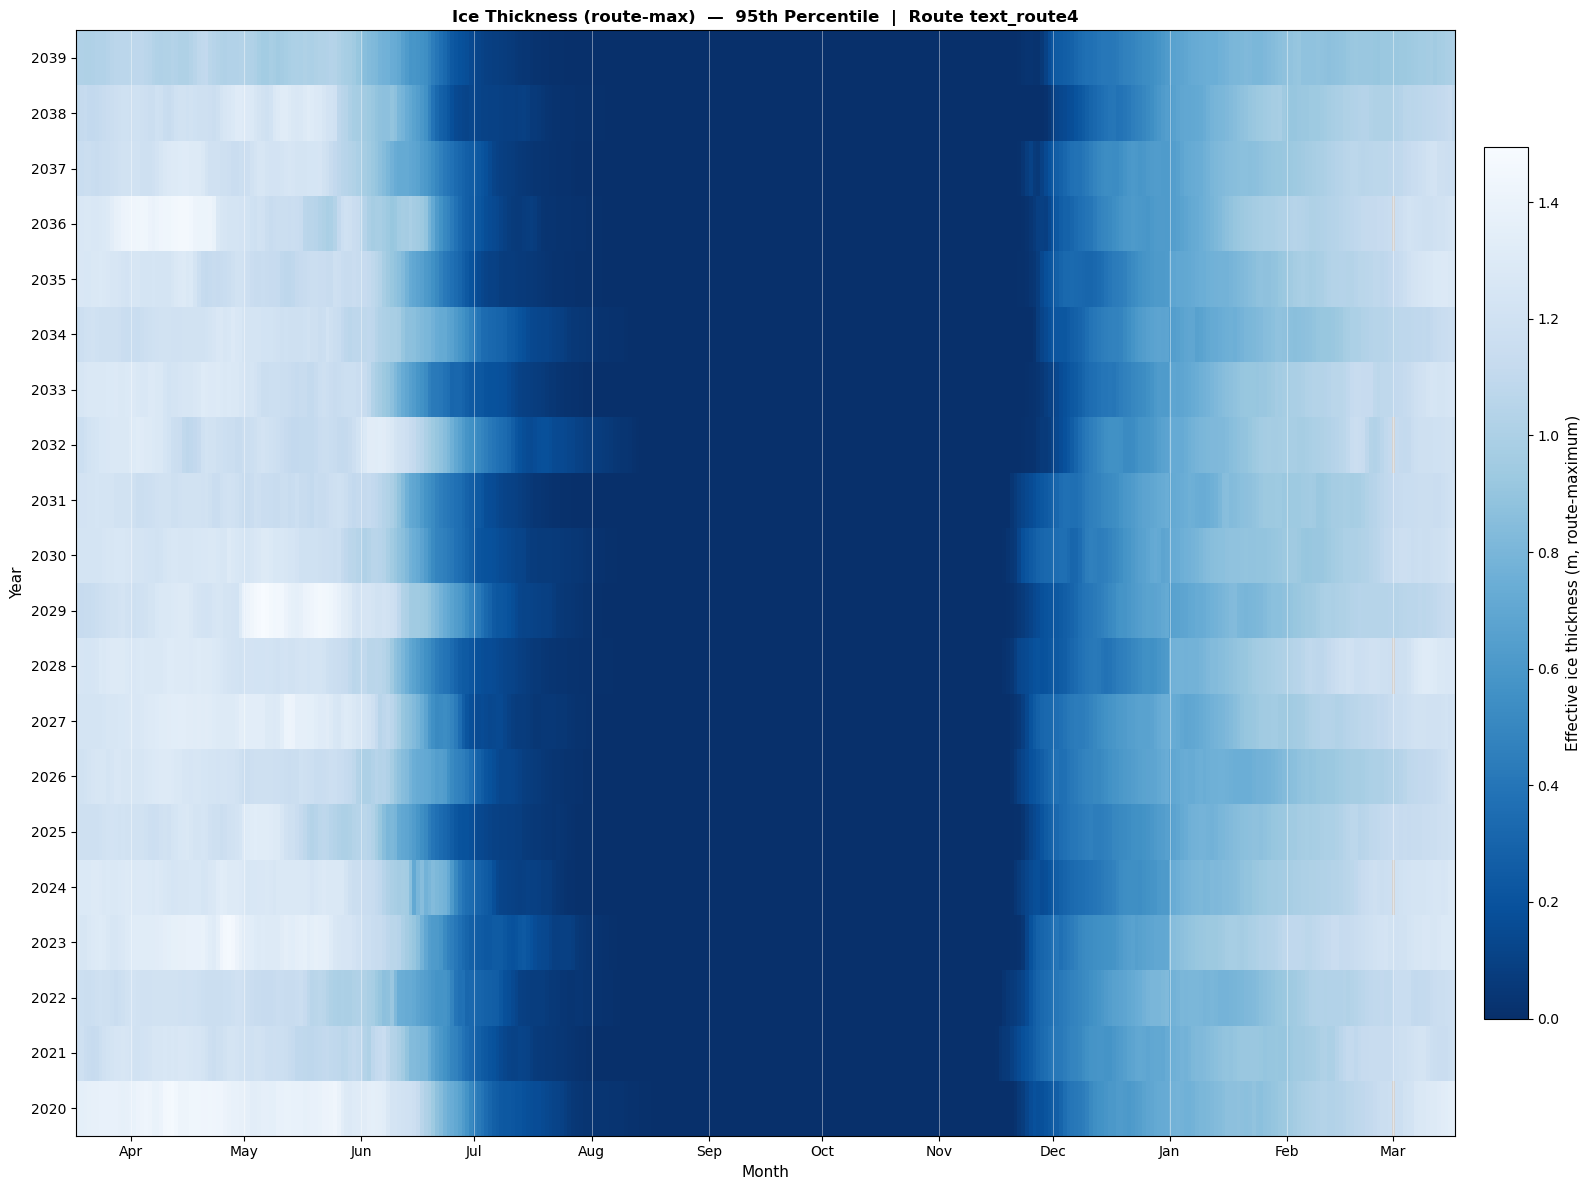

Plotting Conc × Thickness (route-max)  —  5th Percentile ...
  Saved: ../figures/seaice_prod_routetext_route4_5_percentile.png


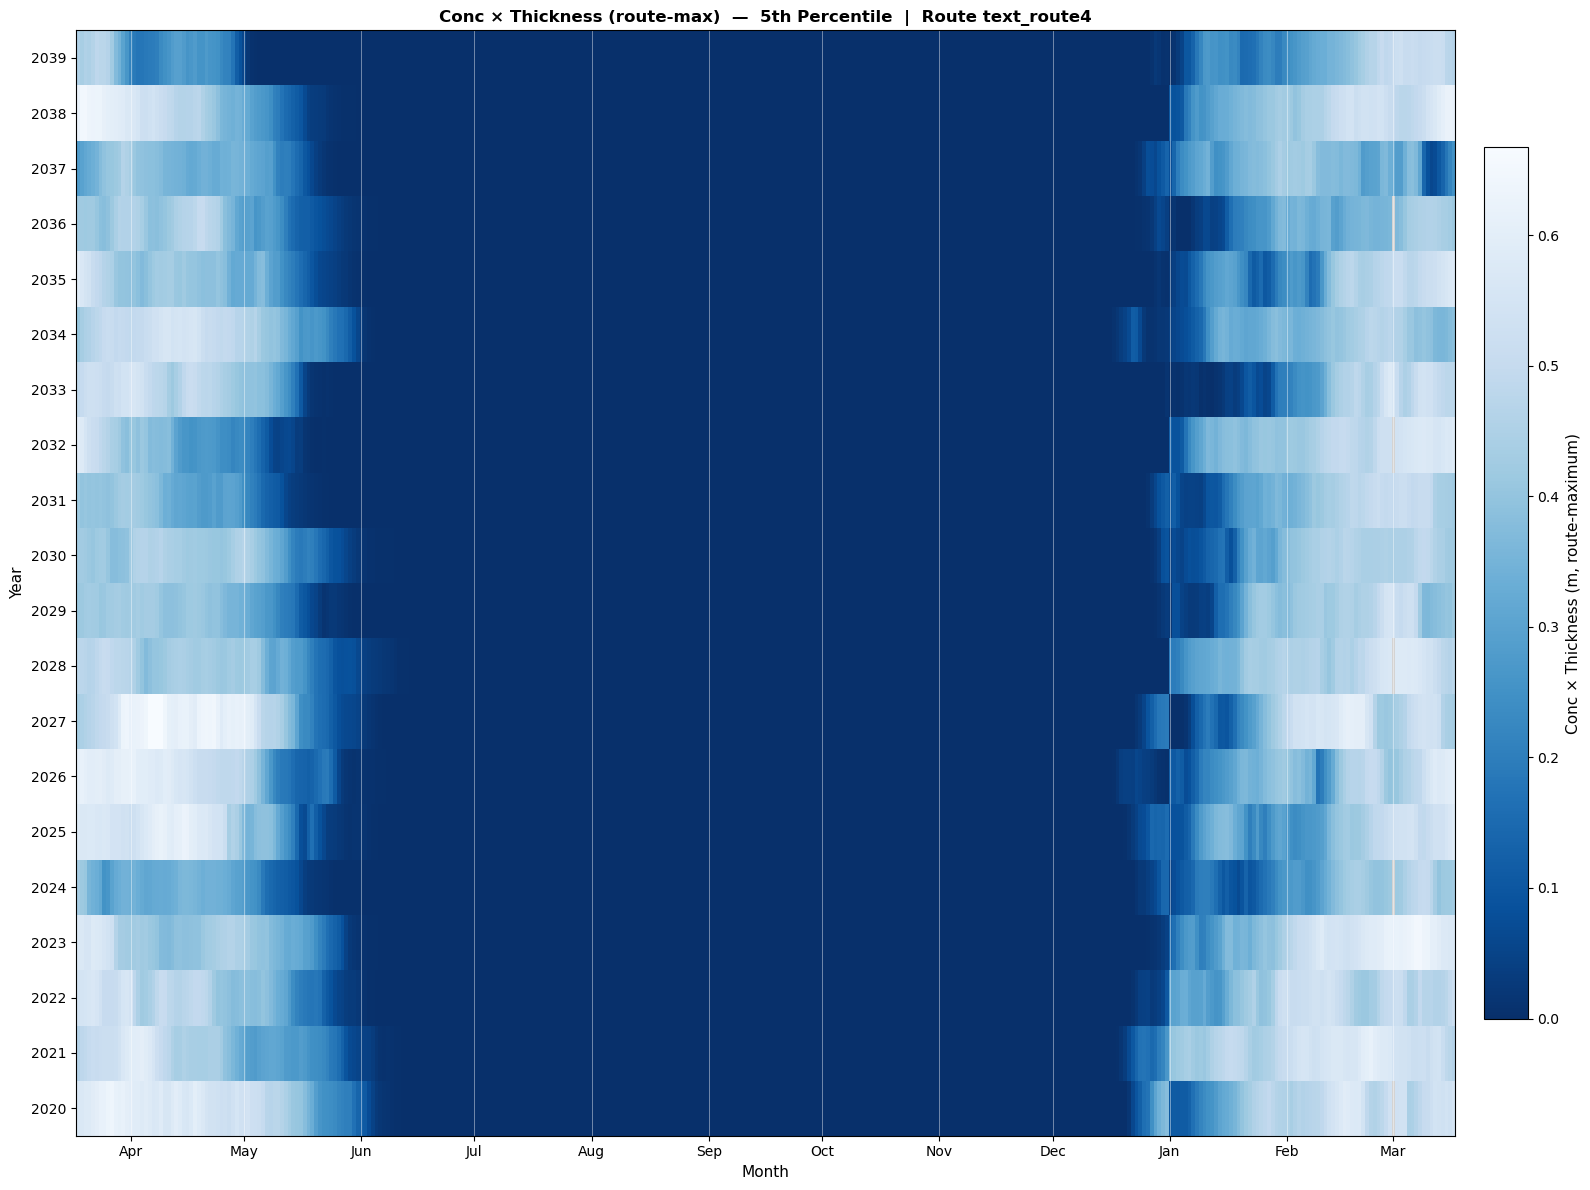

Plotting Conc × Thickness (route-max)  —  Median ...
  Saved: ../figures/seaice_prod_routetext_route4_median.png


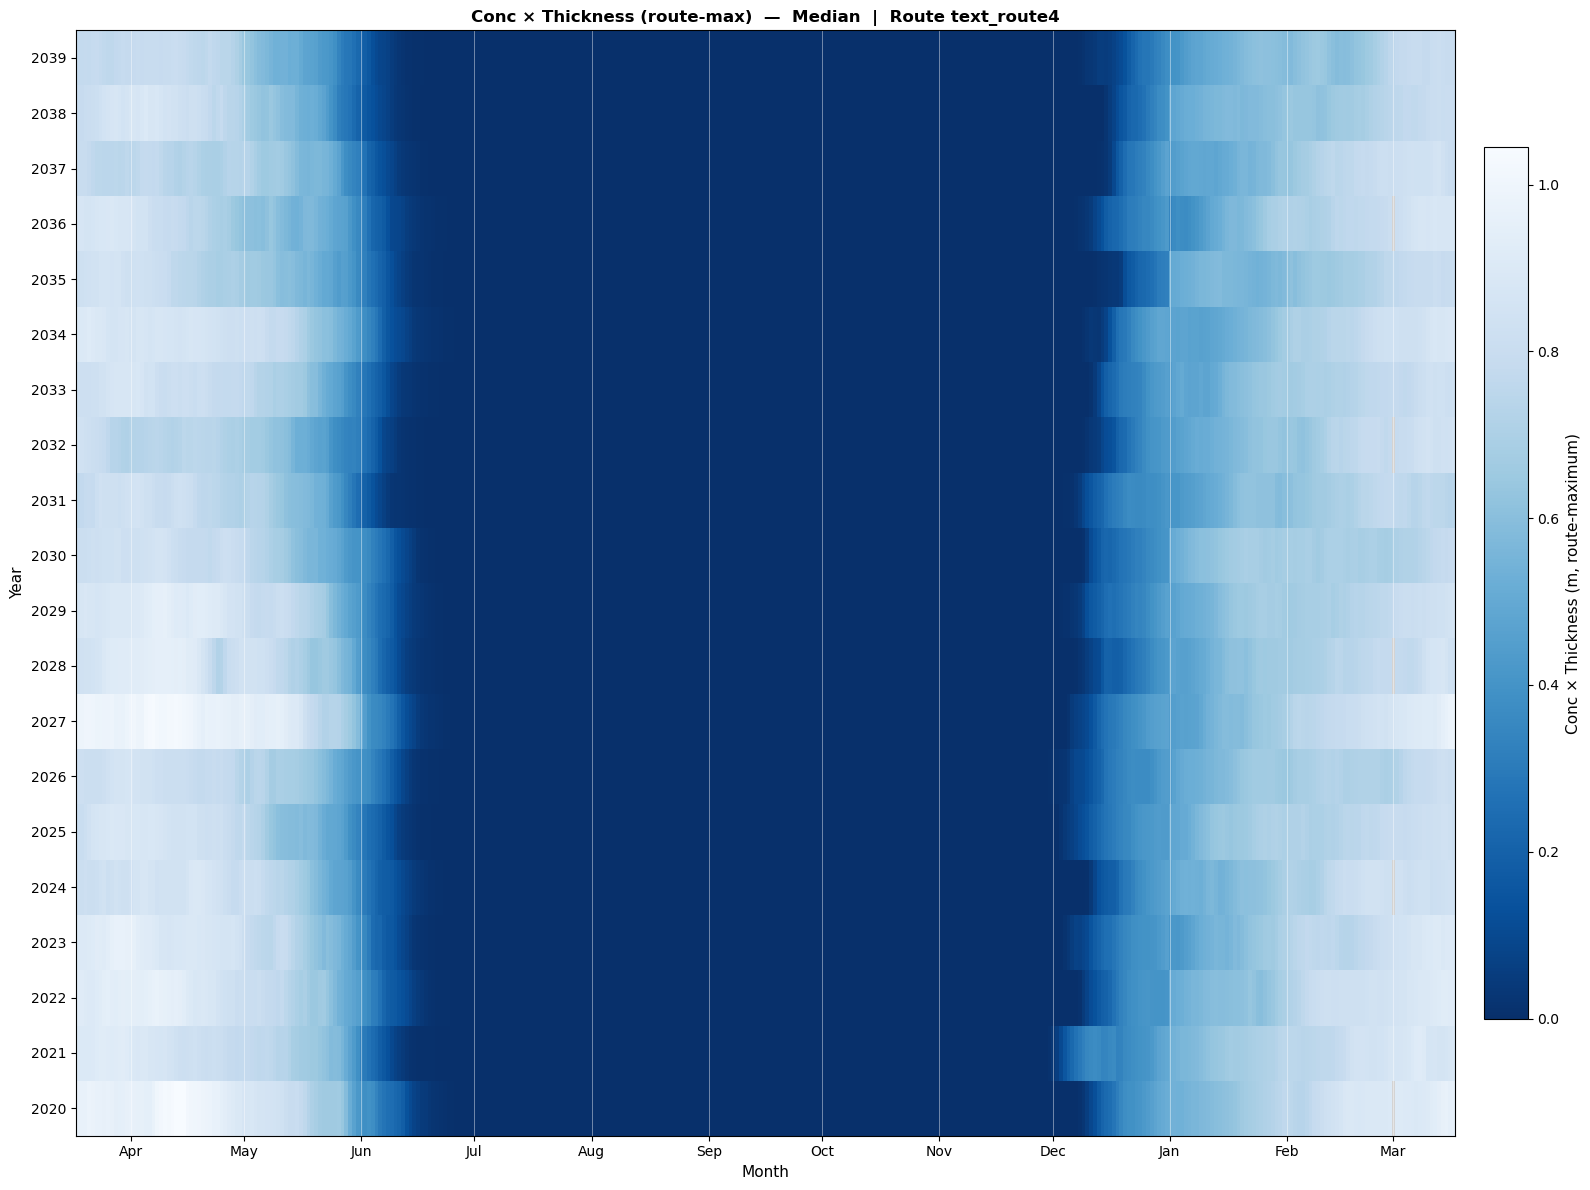

Plotting Conc × Thickness (route-max)  —  95th Percentile ...
  Saved: ../figures/seaice_prod_routetext_route4_95_percentile.png


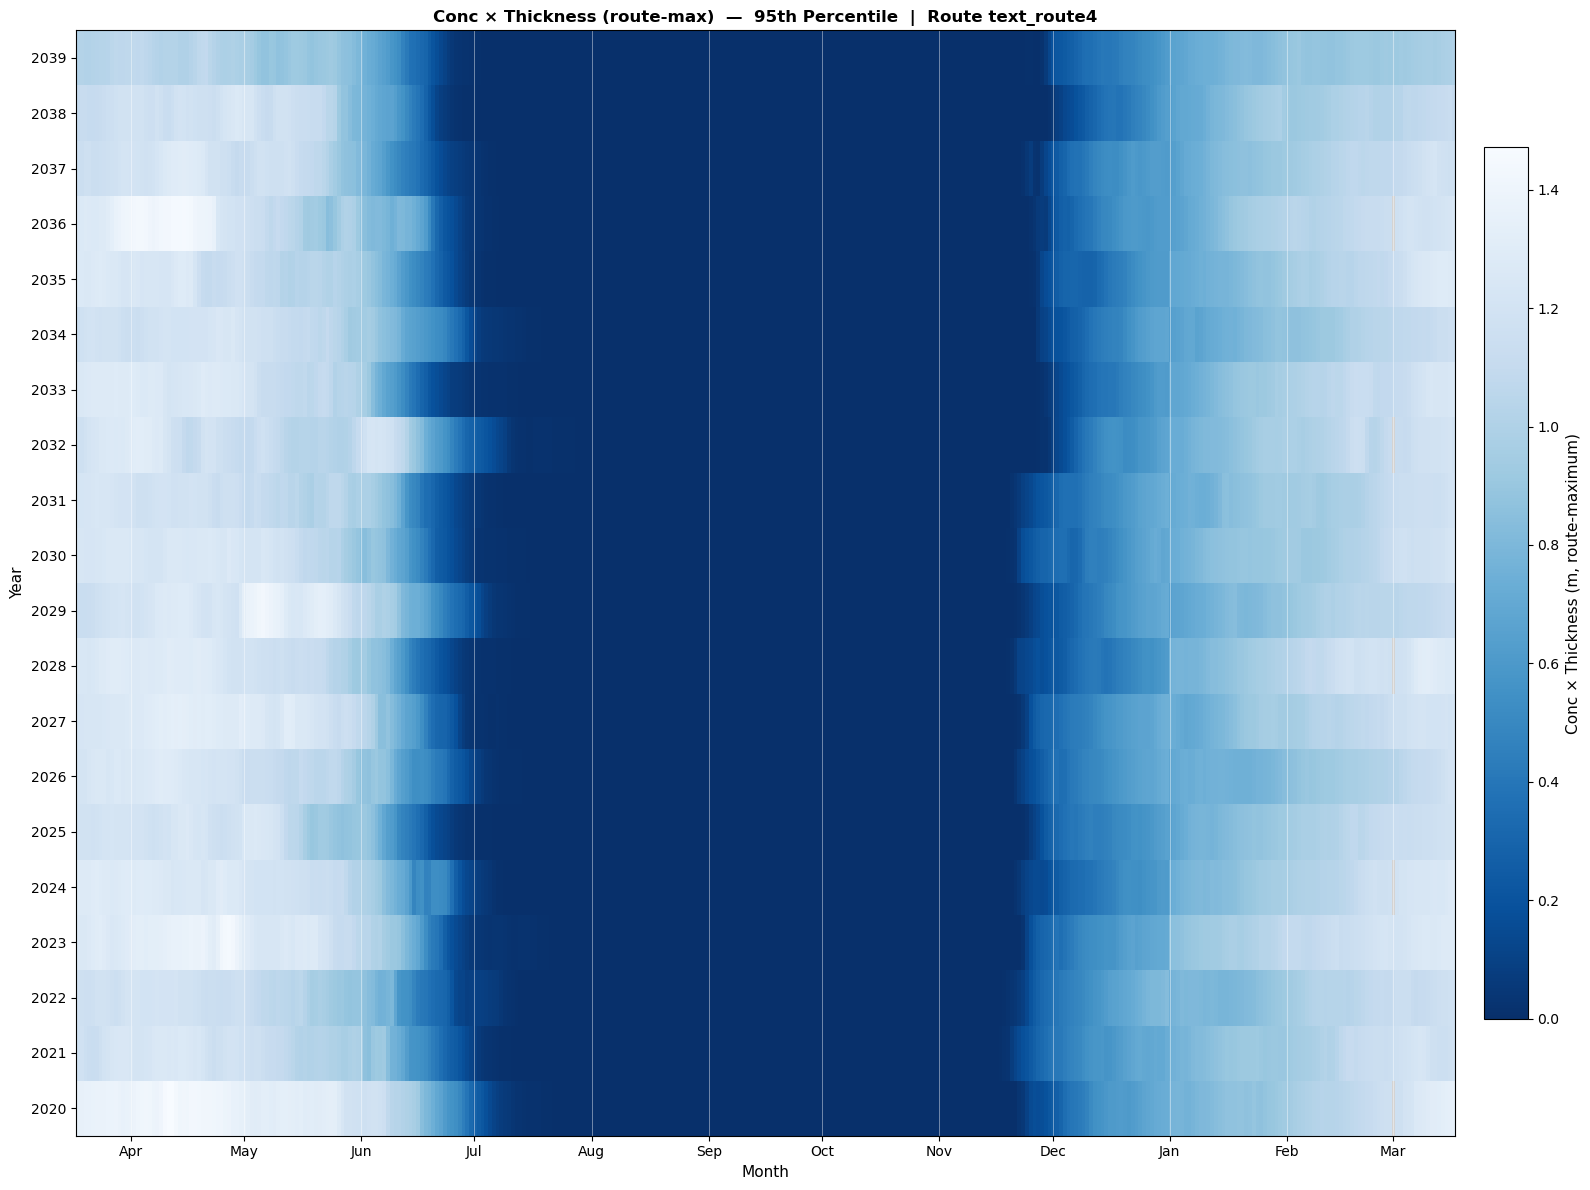

In [15]:
# ---- Generate plots ----
# Three fields × three ensemble statistics = nine heatmaps.

# (data_array, stat_label, field_label, cmap_name, vmin, vmax, cbar_label, field_slug)
plot_specs = [
    # --- Ice Concentration ---
    (max_conc_5th,  '5th Percentile',  'Ice Concentration (route-max)',
     'Blues_r', conc_vmin, conc_vmax,
     'Ice area fraction (route-maximum)', 'conc'),
    (max_conc_med,  'Median',           'Ice Concentration (route-max)',
     'Blues_r', conc_vmin, conc_vmax,
     'Ice area fraction (route-maximum)', 'conc'),
    (max_conc_95th, '95th Percentile',  'Ice Concentration (route-max)',
     'Blues_r', conc_vmin, conc_vmax,
     'Ice area fraction (route-maximum)', 'conc'),
    # --- Ice Thickness (vmax=None -> derived from each plot's data) ---
    (max_thk_5th,  '5th Percentile',   'Ice Thickness (route-max)',
     'Blues_r', thk_vmin, None,
     'Effective ice thickness (m, route-maximum)', 'thk'),
    (max_thk_med,  'Median',            'Ice Thickness (route-max)',
     'Blues_r', thk_vmin, None,
     'Effective ice thickness (m, route-maximum)', 'thk'),
    (max_thk_95th, '95th Percentile',   'Ice Thickness (route-max)',
     'Blues_r', thk_vmin, None,
     'Effective ice thickness (m, route-maximum)', 'thk'),
    # --- Concentration × Thickness product (vmax=None -> derived from each plot's data) ---
    (max_prod_5th,  '5th Percentile',  'Conc \u00d7 Thickness (route-max)',
     'Blues_r', 0.0, None,
     'Conc \u00d7 Thickness (m, route-maximum)', 'prod'),
    (max_prod_med,  'Median',           'Conc \u00d7 Thickness (route-max)',
     'Blues_r', 0.0, None,
     'Conc \u00d7 Thickness (m, route-maximum)', 'prod'),
    (max_prod_95th, '95th Percentile',  'Conc \u00d7 Thickness (route-max)',
     'Blues_r', 0.0, None,
     'Conc \u00d7 Thickness (m, route-maximum)', 'prod'),
]

for (data, stat_label, field_label, cmap_name,
     vmin, vmax, cbar_label, field_slug) in plot_specs:
    print(f'Plotting {field_label}  —  {stat_label} ...')
    make_seaice_heatmap(
        data        = data,
        years       = avail_years,
        field_label = field_label,
        stat_label  = stat_label,
        route_label = route_label,
        save_figs   = save_figs,
        output_dir  = output_dir,
        vmin        = vmin,
        vmax        = vmax,
        cmap_name   = cmap_name,
        cbar_label  = cbar_label,
        field_slug  = field_slug,
        center_doy  = plot_center_doy,
    )


===== Ice Concentration  (Median)  threshold = 0.5 =====
  Spring  (last day >= threshold before summer):
    slope = -0.28 days/yr,  R² = 0.415,  RMSE = 1.9 days,  n = 20
  Fall    (first day >= threshold after summer):
    slope = +0.50 days/yr,  R² = 0.551,  RMSE = 2.6 days,  n = 20
  Saved: ../figures/seaice_conc_trend_routetext_route4_median.png


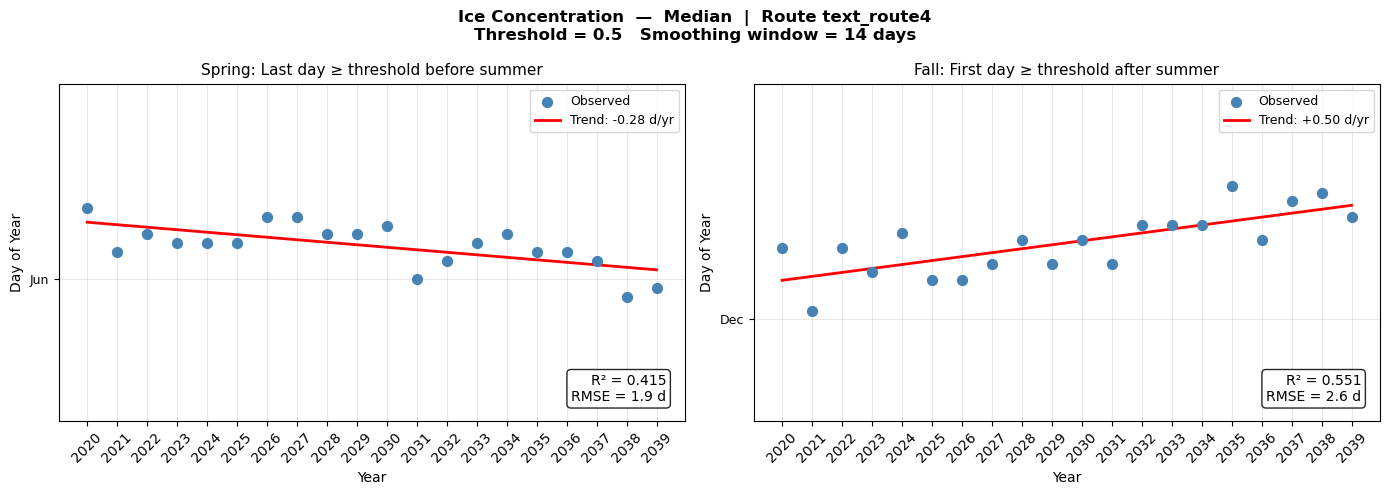


===== Ice Thickness (m)  (Median)  threshold = 0.25 =====
  Spring  (last day >= threshold before summer):
    slope = -0.28 days/yr,  R² = 0.335,  RMSE = 2.2 days,  n = 20
  Fall    (first day >= threshold after summer):
    slope = +0.54 days/yr,  R² = 0.560,  RMSE = 2.8 days,  n = 20
  Saved: ../figures/seaice_thk_trend_routetext_route4_median.png


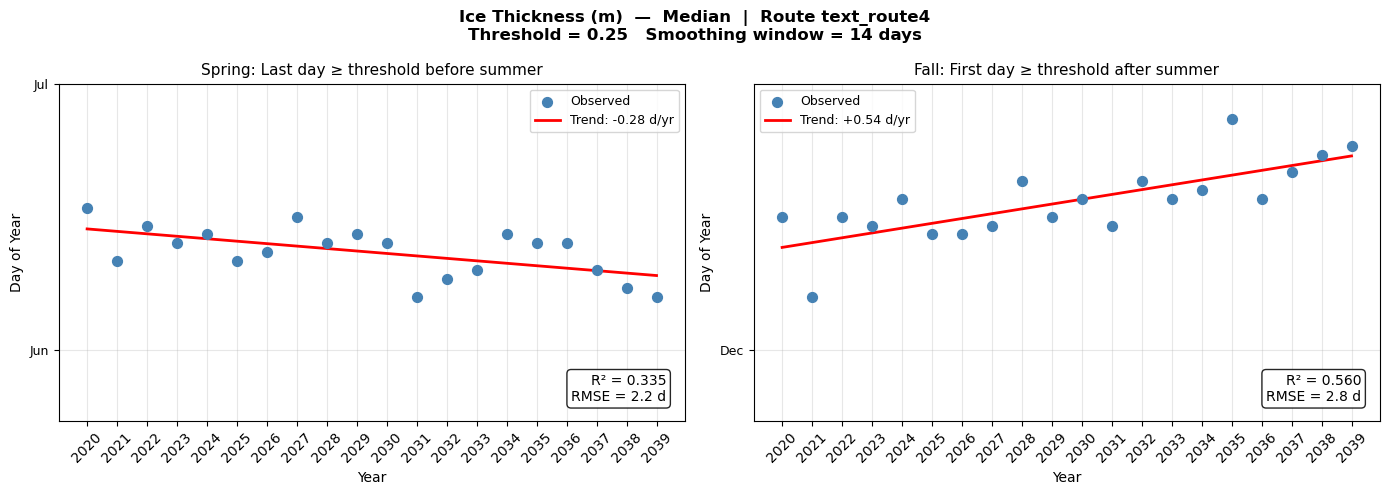


Trend analysis complete.


In [16]:
# ---- Trend analysis: spring and fall threshold crossings ----
# Detects the DOY when concentration and thickness cross trend_threshold_conc /
# trend_threshold_thk in each year, fits linear trends over the year range, and
# saves 2-panel scatter plots (spring | fall) to trend_output_dir.
#
# Results are stored in _trend_results for use by the optional overlay cell below.

import datetime as _dt

# Map trend_stat to data arrays
_stat_arrays = {
    'median':          (max_conc_med,  max_thk_med),
    '5th_percentile':  (max_conc_5th,  max_thk_5th),
    '95th_percentile': (max_conc_95th, max_thk_95th),
}
if trend_stat not in _stat_arrays:
    raise ValueError(
        f"trend_stat must be 'median', '5th_percentile', or '95th_percentile'; "
        f"got '{trend_stat}'"
    )
_conc_data, _thk_data = _stat_arrays[trend_stat]
_stat_label_trend = {
    'median':          'Median',
    '5th_percentile':  '5th Percentile',
    '95th_percentile': '95th Percentile',
}[trend_stat]

# Storage for optional heatmap overlay cell
_trend_results = {}

_analysis_specs = [
    (_conc_data, trend_threshold_conc, 'Ice Concentration', 'conc'),
    (_thk_data,  trend_threshold_thk,  'Ice Thickness (m)',  'thk'),
]

year_arr = np.array(avail_years, dtype=float)

for data, threshold, field_label, field_slug in _analysis_specs:
    print(f'\n===== {field_label}  ({_stat_label_trend})  threshold = {threshold} =====')

    smoothed = smooth_by_year(data, trend_rolling_window)

    spring_doys = np.full(n_years, np.nan)
    fall_doys   = np.full(n_years, np.nan)
    for yi in range(n_years):
        spring_doys[yi] = find_crossing_doy(
            smoothed[yi], threshold,
            trend_spring_doy_range[0], trend_spring_doy_range[1],
            find='last_above',
        )
        fall_doys[yi] = find_crossing_doy(
            smoothed[yi], threshold,
            trend_fall_doy_range[0], trend_fall_doy_range[1],
            find='first_above',
        )

    # Compute and report trends
    print('  Spring  (last day >= threshold before summer):')
    sp_slope, sp_int, sp_r2, sp_rmse, sp_yrs, sp_doys = compute_trend(
        spring_doys, year_arr)
    if not np.isnan(sp_slope):
        print(f'    slope = {sp_slope:+.2f} days/yr,  '
              f'R² = {sp_r2:.3f},  RMSE = {sp_rmse:.1f} days,  n = {len(sp_yrs)}')

    print('  Fall    (first day >= threshold after summer):')
    fa_slope, fa_int, fa_r2, fa_rmse, fa_yrs, fa_doys = compute_trend(
        fall_doys, year_arr)
    if not np.isnan(fa_slope):
        print(f'    slope = {fa_slope:+.2f} days/yr,  '
              f'R² = {fa_r2:.3f},  RMSE = {fa_rmse:.1f} days,  n = {len(fa_yrs)}')

    # Store for overlay
    _trend_results[field_slug] = {
        'spring_doys': spring_doys,
        'fall_doys':   fall_doys,
        'sp_slope': sp_slope, 'sp_int': sp_int, 'sp_r2': sp_r2, 'sp_rmse': sp_rmse,
        'fa_slope': fa_slope, 'fa_int': fa_int, 'fa_r2': fa_r2, 'fa_rmse': fa_rmse,
    }

    # ---- Scatter plot ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'{field_label}  —  {_stat_label_trend}  |  Route {route_label}\n'
        f'Threshold = {threshold}   Smoothing window = {trend_rolling_window} days',
        fontsize=12, fontweight='bold',
    )

    _seasons = [
        ('Spring', 'Last day \u2265 threshold before summer', spring_doys,
         sp_slope, sp_int, sp_r2, sp_rmse),
        ('Fall',   'First day \u2265 threshold after summer',  fall_doys,
         fa_slope, fa_int, fa_r2, fa_rmse),
    ]

    for ax, (season_name, season_desc, all_doys, slope, intercept, r2, rmse) \
            in zip(axes, _seasons):
        valid_mask = ~np.isnan(all_doys)
        ax.scatter(year_arr[valid_mask], all_doys[valid_mask],
                   color='steelblue', s=50, zorder=3, label='Observed')
        if not np.isnan(slope):
            fit_x = np.array([year_arr[valid_mask].min(), year_arr[valid_mask].max()])
            fit_y = slope * fit_x + intercept
            ax.plot(fit_x, fit_y, 'r-', linewidth=2,
                    label=f'Trend: {slope:+.2f} d/yr')
            stats_text = f'R\u00b2 = {r2:.3f}\nRMSE = {rmse:.1f} d'
            ax.text(0.97, 0.05, stats_text, transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
        # y-axis: auto-fit each panel to its data range, or use user-specified limits
        if trend_scatter_ylim is not None:
            _ylo, _yhi = trend_scatter_ylim
        else:
            if valid_mask.any():
                _pad = 14  # days of padding on each side
                _ylo = max(0,   float(np.nanmin(all_doys[valid_mask])) - _pad)
                _yhi = min(364, float(np.nanmax(all_doys[valid_mask])) + _pad)
            else:
                _ylo, _yhi = 0, 364
        _vis_ticks  = [d for d in _MONTH_DOY if _ylo <= d <= _yhi]
        _vis_labels = [_MONTH_NAMES[i] for i, d in enumerate(_MONTH_DOY) if _ylo <= d <= _yhi]
        ax.set_yticks(_vis_ticks)
        ax.set_yticklabels(_vis_labels, fontsize=9)
        ax.set_ylim(_ylo, _yhi)
        ax.yaxis.grid(True, alpha=0.3)
        ax.set_title(f'{season_name}: {season_desc}', fontsize=11)
        ax.set_xlabel('Year', fontsize=10)
        ax.set_ylabel('Day of Year', fontsize=10)
        ax.set_xticks(year_arr.astype(int))
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_figs:
        os.makedirs(trend_output_dir, exist_ok=True)
        _stat_slug_trend = (
            _stat_label_trend.lower()
            .replace(' ', '_').replace('th', '').replace('st', '')
        )
        fname = os.path.join(
            trend_output_dir,
            f'seaice_{field_slug}_trend_route{route_label}_{_stat_slug_trend}.png',
        )
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'  Saved: {fname}')

    plt.show()
    plt.close(fig)

print('\nTrend analysis complete.')


Plotting Ice Concentration (route-max)  —  Median  (with trend overlay) ...
  Saved: ../figures/seaice_conc_routetext_route4_median_trend.png


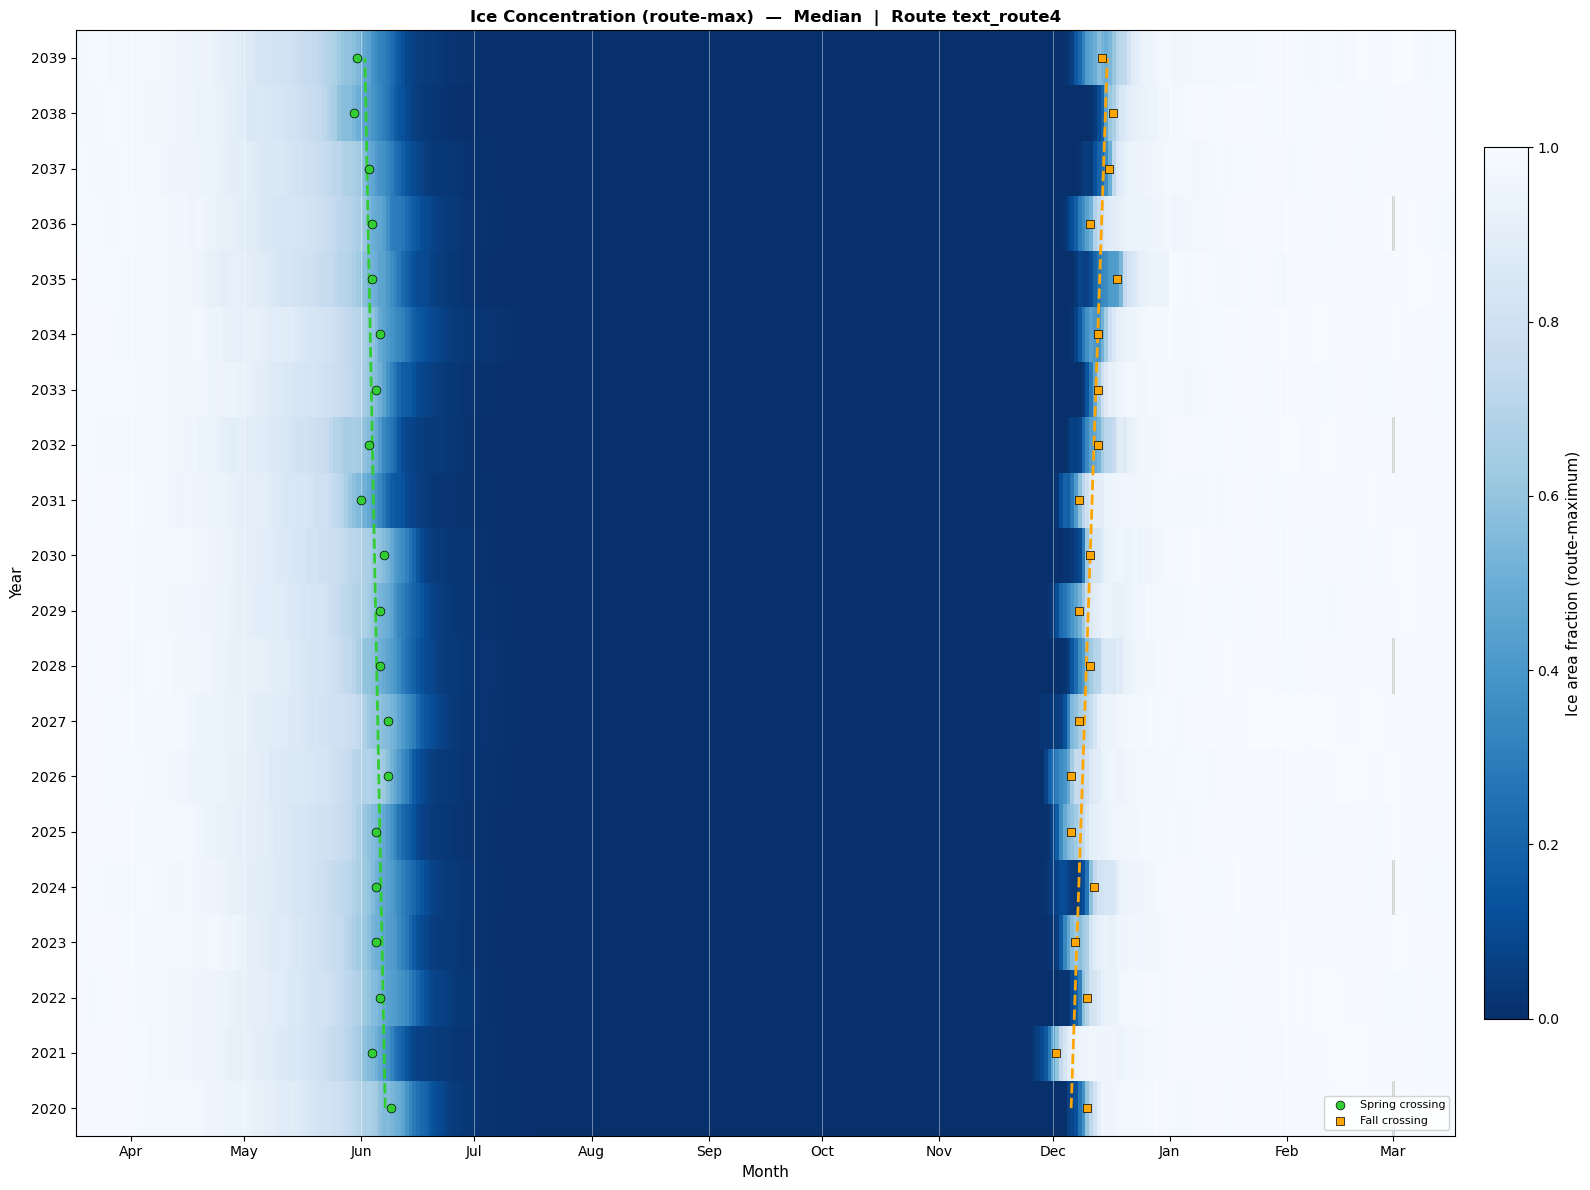

Plotting Ice Thickness (route-max)  —  Median  (with trend overlay) ...
  Saved: ../figures/seaice_thk_routetext_route4_median_trend.png


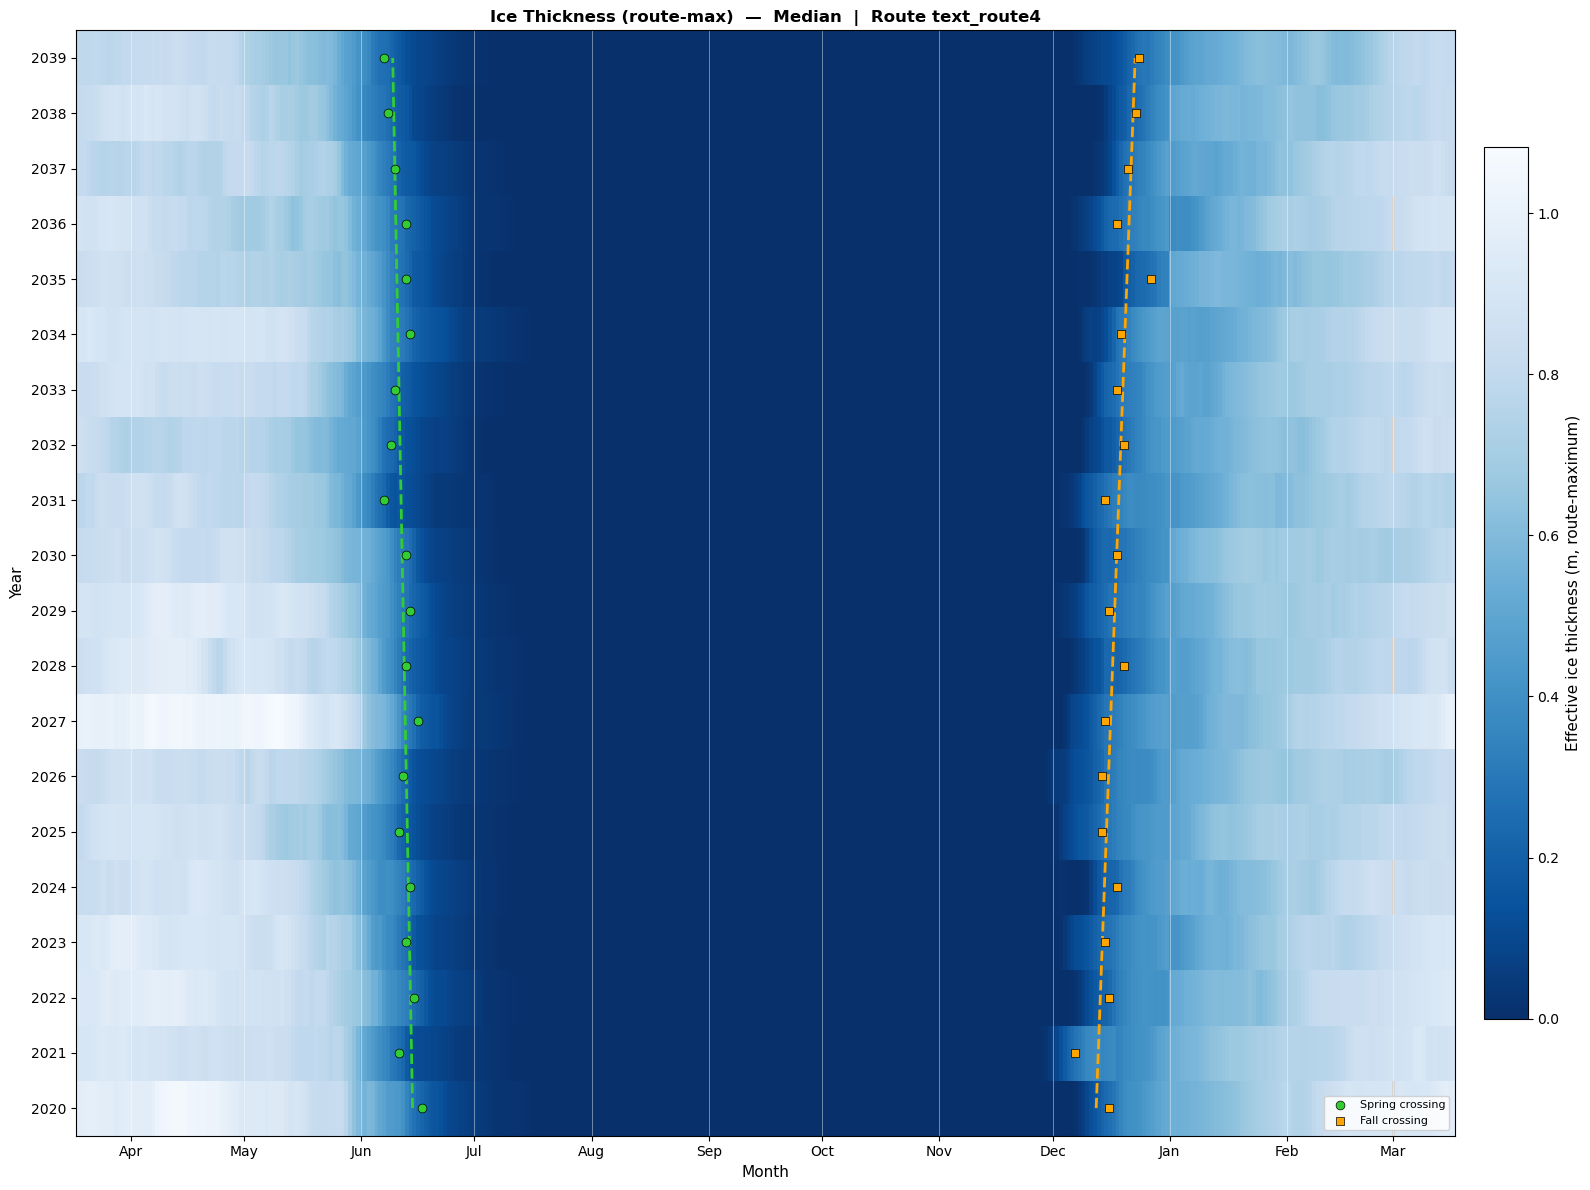

In [17]:
# ---- Optional: heatmap with trend overlay ----
# Run this cell independently to regenerate the concentration and thickness
# heatmaps for the selected trend_stat, with threshold-crossing scatter points
# and linear trend lines overlaid.
#
# Requires the trend analysis cell above to have been run first so that
# _trend_results is populated.  The overlaid heatmaps are saved with a
# '_trend' suffix to avoid overwriting the clean versions.

if '_trend_results' not in dir() or not _trend_results:
    raise RuntimeError(
        'Run the trend analysis cell above first to populate _trend_results.'
    )

# Resolve stat label (self-contained so this cell can run independently)
_stat_label_overlay = {
    'median':          'Median',
    '5th_percentile':  '5th Percentile',
    '95th_percentile': '95th Percentile',
}.get(trend_stat, trend_stat)

# Rolled x-axis offset used by make_seaice_heatmap
_n_days_overlay = 365
_start_doy_overlay = (plot_center_doy - _n_days_overlay // 2) % _n_days_overlay


def _to_rolled(doy):
    return (doy - _start_doy_overlay) % _n_days_overlay


# (data_array, field_label, vmin, vmax, cmap, cbar_label, field_slug)
_stat_map = {
    'median':          (max_conc_med,  max_thk_med),
    '5th_percentile':  (max_conc_5th,  max_thk_5th),
    '95th_percentile': (max_conc_95th, max_thk_95th),
}
_c_data, _t_data = _stat_map[trend_stat]

_overlay_specs = [
    (_c_data, 'Ice Concentration (route-max)',
     conc_vmin, conc_vmax, 'Blues_r',
     'Ice area fraction (route-maximum)', 'conc'),
    (_t_data, 'Ice Thickness (route-max)',
     thk_vmin, None, 'Blues_r',
     'Effective ice thickness (m, route-maximum)', 'thk'),
]

for (data, field_label, vmin, vmax, cmap_name, cbar_label, field_slug) \
        in _overlay_specs:
    res = _trend_results.get(field_slug)
    if res is None:
        print(f'No trend results for {field_slug} — skipping.')
        continue

    # Build overlay dicts in heatmap coordinate space (y = year index, x = rolled DOY)
    trend_overlay_arg = {}
    for season_key, doys_key, slope_key, int_key in [
        ('spring', 'spring_doys', 'sp_slope', 'sp_int'),
        ('fall',   'fall_doys',   'fa_slope', 'fa_int'),
    ]:
        all_doys = res[doys_key]
        valid    = ~np.isnan(all_doys)
        trend_overlay_arg[season_key] = {
            'yi':        np.where(valid)[0].astype(float),
            'rolled_x':  np.array([_to_rolled(d) for d in all_doys[valid]]),
            'slope':     res[slope_key],
            'intercept': res[int_key],
        }

    print(f'Plotting {field_label}  —  {_stat_label_overlay}  (with trend overlay) ...')
    make_seaice_heatmap(
        data          = data,
        years         = avail_years,
        field_label   = field_label,
        stat_label    = _stat_label_overlay,
        route_label   = route_label,
        save_figs     = save_figs,
        output_dir    = output_dir,
        vmin          = vmin,
        vmax          = vmax,
        cmap_name     = cmap_name,
        cbar_label    = cbar_label,
        field_slug    = field_slug,
        center_doy    = plot_center_doy,
        trend_overlay = trend_overlay_arg,
    )
